In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/alltiles_LRGzinfo_mw_trans_added.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS', 'subset'])
idx = np.where((tmp['subset']=='deep') & (tmp['TARGETS']=='QSO+LRG'))[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

34868
34702


In [4]:
# # Print summary of the tiles
# t = Table()
# t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
# t['efftime'] = 0
# t['n_exp'] = 0
# for index, tileid in enumerate(t['TILEID']):
#     mask = zbest['TILEID']==tileid
#     t['n_exp'][index] = np.max(zbest['COADD_NUMEXP'][mask])
#     t['efftime'][index] = np.max(zbest['EFFTIME_DARK'][mask])
# t

In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 18686 10684 0.636227442969016
18686


In [6]:
# Ting-Wen's quality cuts
mask = zbest['DELTACHI2']>20
mask &= zbest['Z']<1.4

mask &= zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 18202 484 0.9740982553783581
18202


In [7]:
# Apply WISE W1 mask
mask = zbest['MASKBITS'] & 2**8==0
print('WISE mask', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

WISE mask 17593 609 0.9665421382265685
17593


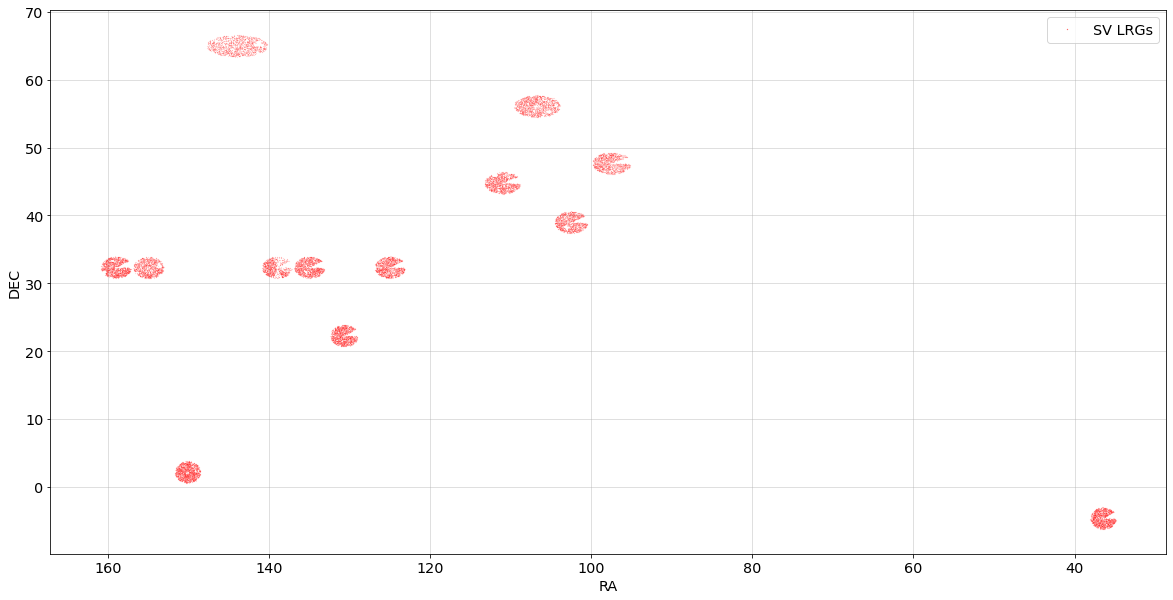

In [8]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [9]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

In [10]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [11]:
# Changelog:
# - Add GAIA_G>18 cut
# - Revised low-z (g-r vs r-W1) cuts from Jeff (same north and south cuts)
# - Shift the low-z cut intercept by 0.1 in the north (decreasing the density), to account for the north vs south difference
# - Shift the sliding IR cut intercept by 0.05*1.8 (increasing the density), to match the optical target density

# mask_north = cat['PHOTSYS']=='N'
# mask_south = cat['PHOTSYS']=='S'

#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

4773
4935


In [12]:
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
# lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
# lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
# print(np.sum(lrg_opt))
# print(np.sum(lrg_ir))
# print(np.sum(lrg_sv))
# print()

sv_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(sv_qso & lrg_sv), '{:.2f}%'.format(np.sum(sv_qso & lrg_sv)/np.sum(lrg_sv)*100))
print(np.sum(sv_qso & lrg_opt), '{:.2f}%'.format(np.sum(sv_qso & lrg_opt)/np.sum(lrg_opt)*100))
print(np.sum(sv_qso & lrg_ir), '{:.2f}%'.format(np.sum(sv_qso & lrg_ir)/np.sum(lrg_ir)*100))

383 2.18%
32 0.67%
120 2.43%


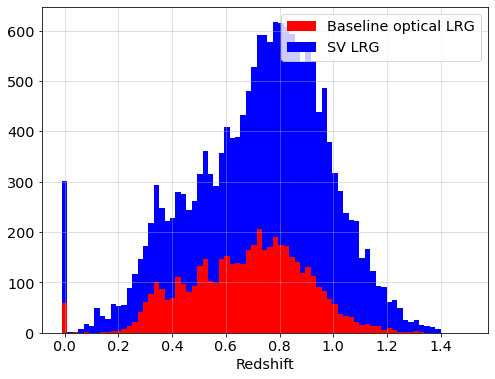

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=75, range=(-0.01, 1.5), color='red', label='Baseline optical LRG', zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=75, range=(-0.01, 1.5), color='blue', label='SV LRG', zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

In [14]:
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)
mask_qso = zbest['SPECTYPE']=='QSO'

# Force the very low-z objects to have SPECTYPE=STAR
zbest['SPECTYPE'][mask_star] = 'STAR'

In [15]:
print('Stars in LRG_SV: {:.1f}% ({}/{})'.format(np.sum(mask_star & lrg_sv)/np.sum(lrg_sv)*100, np.sum(mask_star & lrg_sv), np.sum(lrg_sv)))
print('Stars in LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_star & lrg_opt)/np.sum(lrg_opt)*100, np.sum(mask_star & lrg_opt), np.sum(lrg_opt)))
print('Stars in LRG_IR: {:.1f}% ({}/{})'.format(np.sum(mask_star & lrg_ir)/np.sum(lrg_ir)*100, np.sum(mask_star & lrg_ir), np.sum(lrg_ir)))

Stars in LRG_SV: 1.7% (300/17593)
Stars in LRG_OPT: 1.3% (60/4773)
Stars in LRG_IR: 0.6% (28/4935)


In [16]:
print('Excluding QSO targets:')
print('Stars in LRG_SV: {:.1f}% ({}/{})'.format(np.sum((~sv_qso) & mask_star & lrg_sv)/np.sum(lrg_sv & (~sv_qso))*100, np.sum((~sv_qso) & mask_star & lrg_sv), np.sum(lrg_sv & (~sv_qso))))
print('Stars in LRG_OPT: {:.1f}% ({}/{})'.format(np.sum((~sv_qso) & mask_star & lrg_opt)/np.sum(lrg_opt & (~sv_qso))*100, np.sum((~sv_qso) & mask_star & lrg_opt), np.sum(lrg_opt & (~sv_qso))))
print('Stars in LRG_IR: {:.1f}% ({}/{})'.format(np.sum((~sv_qso) & mask_star & lrg_ir)/np.sum(lrg_ir & (~sv_qso))*100, np.sum((~sv_qso) & mask_star & lrg_ir), np.sum(lrg_ir & (~sv_qso))))

Excluding QSO targets:
Stars in LRG_SV: 1.4% (239/17210)
Stars in LRG_OPT: 0.9% (45/4741)
Stars in LRG_IR: 0.4% (19/4815)


In [17]:
print('Only QSO targets:')
print('Stars in LRG_SV: {:.1f}% ({}/{})'.format(np.sum((sv_qso) & mask_star & lrg_sv)/np.sum(lrg_sv & (sv_qso))*100, np.sum((sv_qso) & mask_star & lrg_sv), np.sum(lrg_sv & (sv_qso))))
print('Stars in LRG_OPT: {:.1f}% ({}/{})'.format(np.sum((sv_qso) & mask_star & lrg_opt)/np.sum(lrg_opt & (sv_qso))*100, np.sum((sv_qso) & mask_star & lrg_opt), np.sum(lrg_opt & (sv_qso))))
print('Stars in LRG_IR: {:.1f}% ({}/{})'.format(np.sum((sv_qso) & mask_star & lrg_ir)/np.sum(lrg_ir & (sv_qso))*100, np.sum((sv_qso) & mask_star & lrg_ir), np.sum(lrg_ir & (sv_qso))))

Only QSO targets:
Stars in LRG_SV: 15.9% (61/383)
Stars in LRG_OPT: 46.9% (15/32)
Stars in LRG_IR: 7.5% (9/120)


Lowest non-STAR redshift: 0.002555975549533229


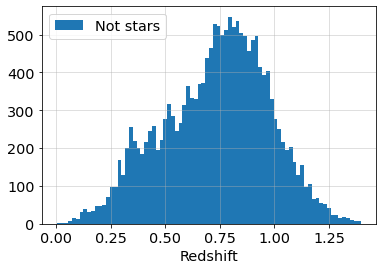

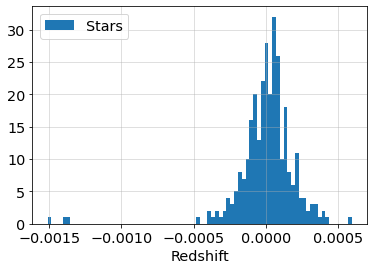

In [18]:
print('Lowest non-STAR redshift: {:}'.format(zbest['Z'][~mask_star].min()))

plt.hist(zbest['Z'][~mask_star], bins=80, label='Not stars')
plt.xlabel('Redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.hist(zbest['Z'][mask_star], bins=80, label='Stars')
plt.xlabel('Redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

SV LRG
300 0.01705223668504519


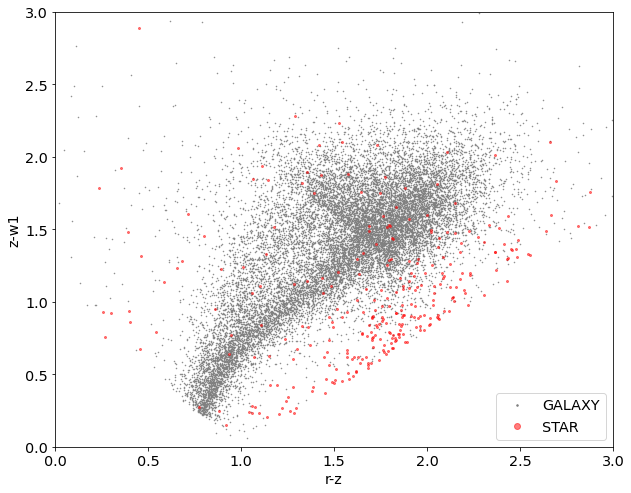

239 0.013887274840209182


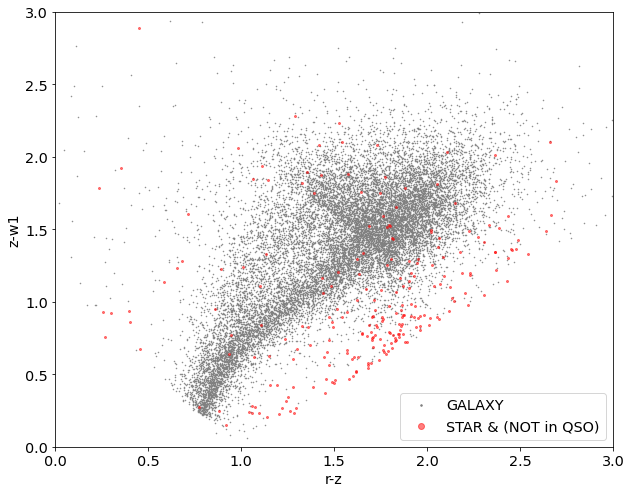

In [19]:
print('SV LRG')
print(np.sum(mask_star), np.sum(mask_star)/len(zbest))
plt.figure(figsize=(10, 8))
plt.plot((zbest['rmag']-zbest['zmag'])[mask_gal], (zbest['zmag']-zbest['w1mag'])[mask_gal], '.', color='0.5', ms=1, label='GALAXY')
plt.plot((zbest['rmag']-zbest['zmag'])[mask_star],( zbest['zmag']-zbest['w1mag'])[mask_star], 'r.', ms=4, label='STAR', alpha=0.5)
plt.xlabel('r-z')
plt.ylabel('z-w1')
plt.axis([0, 3, 0, 3])
plt.legend(markerscale=3)
plt.legend(markerscale=3, loc='lower right')
plt.show()

mask1 = mask_star & (~sv_qso)
print(np.sum(mask1), np.sum(mask1)/np.sum(~sv_qso))
plt.figure(figsize=(10, 8))
plt.plot((zbest['rmag']-zbest['zmag'])[mask_gal], (zbest['zmag']-zbest['w1mag'])[mask_gal], '.', color='0.5', ms=1, label='GALAXY')
plt.plot((zbest['rmag']-zbest['zmag'])[mask1],( zbest['zmag']-zbest['w1mag'])[mask1], 'r.', ms=4, label='STAR & (NOT in QSO)', alpha=0.5)
plt.xlabel('r-z')
plt.ylabel('z-w1')
plt.axis([0, 3, 0, 3])
plt.legend(markerscale=3, loc='lower right')
plt.show()

In [20]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [21]:
def color_plot_3x2_simple(cat, color_col, idx=None, title=None, vmin=0.2, vmax=1.0, cmap='Dark2_r', ms=0.3, show=True, figaxis=None, colorbar=True, figsize=(18, 20), grid=False):
    '''
    Replace the g-r vs r-z panel with g-r vs r-W1
    '''
    if idx is None:
        idx = np.arange(len(cat))

    if figaxis is None:
        fig, axes = plt.subplots(3, 2, figsize=figsize)
    else:
        fig, axes = figaxis

    # non-stellar cut
    x = np.linspace(-10, 10)
    y = (x - 0.6) * 0.8
    axes[0, 0].plot(x, y, '--', lw=2, color='r')
    im = axes[0, 0].scatter((cat['rmag']-cat['zmag'])[idx], (cat['zmag']-cat['w1mag'])[idx], 
                c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 0].set_xlabel('r - z')
    axes[0, 0].set_ylabel('z - W1')
    axes[0, 0].axis([-0.2, 3, -0.5, 3.5])
    if colorbar:
        fig.colorbar(im, ax=axes[0, 0])
    if grid:
        axes[0, 0].grid(alpha=0.5)

    # g-r vs r-W1
    im = axes[0, 1].scatter((cat['rmag']-cat['w1mag'])[idx], (cat['gmag']-cat['rmag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 1].set_xlabel('r - w1')
    axes[0, 1].set_ylabel('g - r')
    axes[0, 1].axis([0., 5.5, 0, 3])
    if colorbar:
        fig.colorbar(im, ax=axes[0, 1])
    if grid:
        axes[0, 1].grid(alpha=0.5)

    # optical sliding cut
    x = np.linspace(19, 100)
    y = (x - 16.83) * 0.45
    axes[1, 0].plot(x, y, '--', lw=2, color='r')
    x = np.linspace(0, 19)
    y = (x - 13.80) * 0.19
    axes[1, 0].plot(x, y, '--', lw=2, color='r')
    im = axes[1, 0].scatter((cat['zmag'])[idx], (cat['rmag']-cat['zmag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 0].set_xlabel('z')
    axes[1, 0].set_ylabel('r - z')
    axes[1, 0].axis([17, 22., 0.5, 3])
    if colorbar:
        fig.colorbar(im, ax=axes[1, 0])
    if grid:
        axes[1, 0].grid(alpha=0.5)
    x = np.linspace(17, 22)

    # IR sliding cut
    x = np.linspace(18.25, 100)
    y = (x - 17.22) * 1.8
    axes[1, 1].plot(x, y, '--', lw=2, color='r')
    x = np.linspace(0, 18.25)
    y = (x - 16.37) * 1.
    axes[1, 1].plot(x, y, '--', lw=2, color='r')
    im = axes[1, 1].scatter((cat['w1mag'])[idx], (cat['rmag']-cat['w1mag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 1].set_xlabel('W1')
    axes[1, 1].set_ylabel('r - W1')
    axes[1, 1].axis([16.3, 21., 0.3, 5.])
    if colorbar:
        fig.colorbar(im, ax=axes[1, 1])
    if grid:
        axes[1, 1].grid(alpha=0.5)
    
    # zfiber vs z
    im = axes[2, 0].scatter((cat['zmag'])[idx], (cat['zfibermag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[2, 0].set_xlabel('z')
    axes[2, 0].set_ylabel('zfiber')
    axes[2, 0].axis([17, 22., 18, 23.])
    if colorbar:
        fig.colorbar(im, ax=axes[2, 0])
    if grid:
        axes[2, 0].grid(alpha=0.5)

    axes[2, 1].axis('off')

    if title is not None:
        fig.suptitle(title)
    fig.subplots_adjust(top=0.96)
    
    if show:
        plt.show()
    else:
        return fig, axes

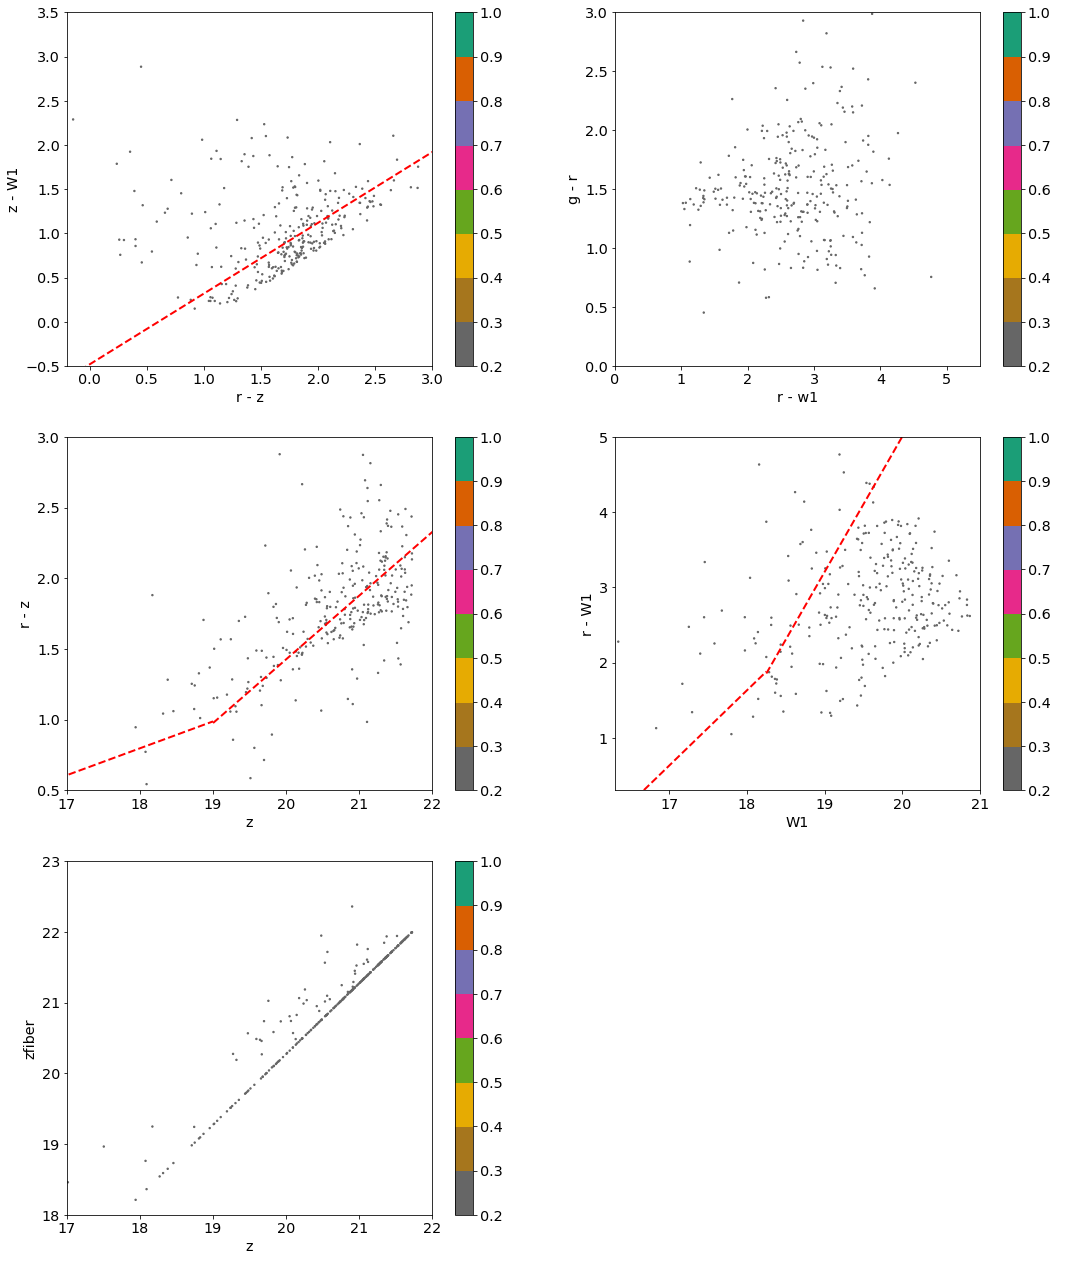

In [22]:
color_plot_3x2_simple(zbest[mask_star], color_col='Z', ms=2)

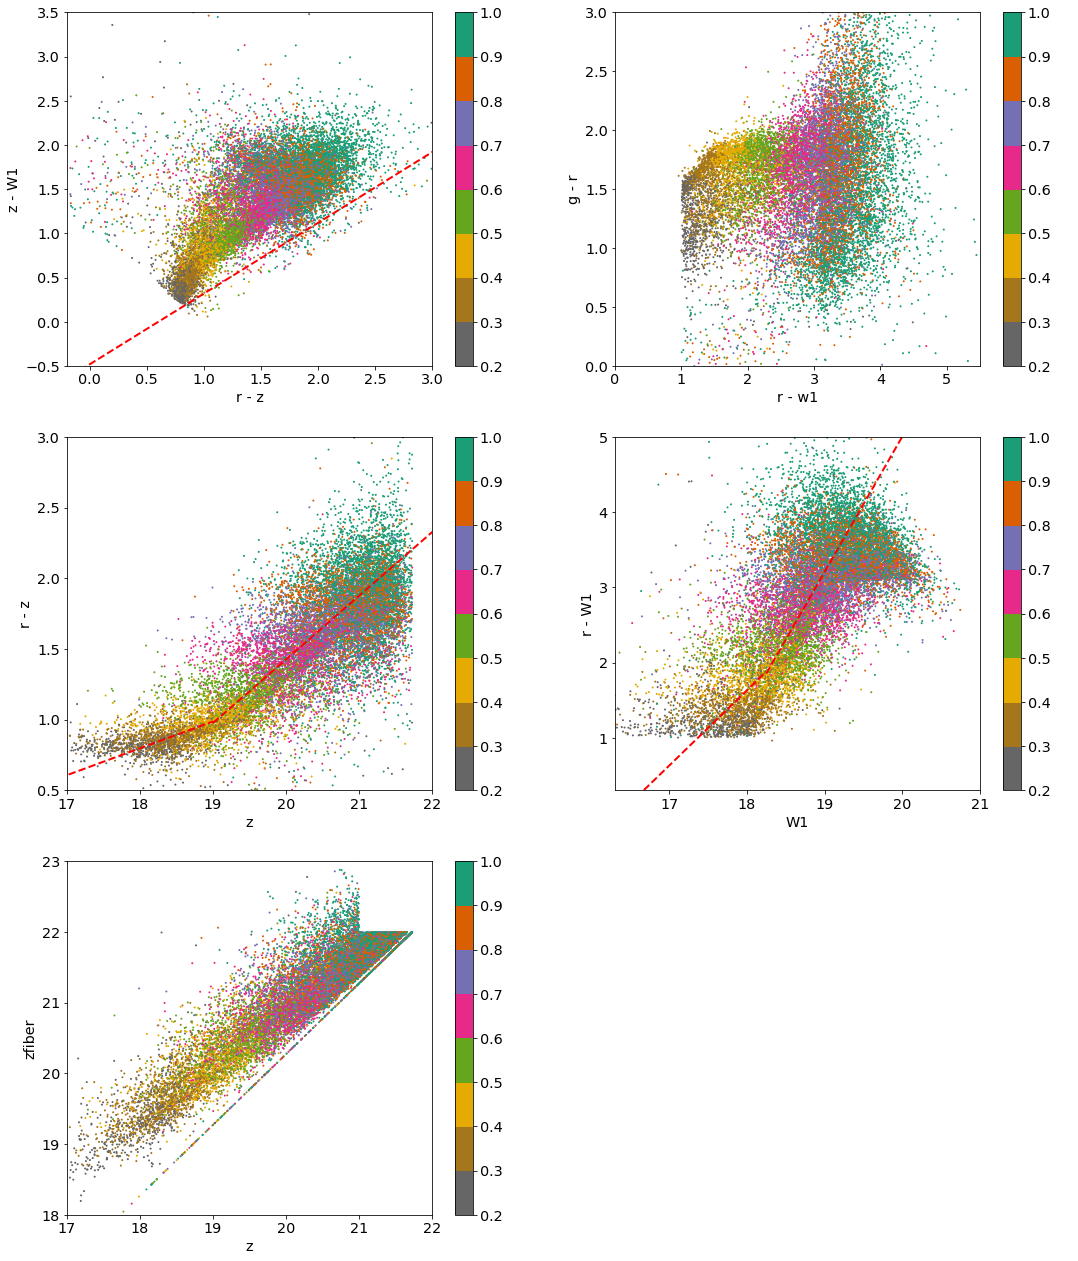

In [23]:
color_plot_3x2_simple(zbest[~mask_star], color_col='Z', ms=1)

-----
## SPECTYPE of PSF objects

In [24]:
print("All PSF objects in LRG_SV")
mask = zbest['MORPHTYPE']=='PSF'
t = Table()
t['type'], t['count'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All PSF objects in LRG_SV


type,count,frac (%)
str6,int64,float64
QSO,162,13.9
STAR,249,21.4
GALAXY,751,64.6


In [25]:
print("All PSF objects in LRG_OPT")
mask = zbest['MORPHTYPE']=='PSF'
mask &= lrg_opt
t = Table()
t['type'], t['count'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All PSF objects in LRG_OPT


type,count,frac (%)
str6,int64,float64
QSO,4,4.1
GALAXY,46,47.4
STAR,47,48.5


In [26]:
print("All PSF objects in LRG_ir")
mask = zbest['MORPHTYPE']=='PSF'
mask &= lrg_ir
t = Table()
t['type'], t['count'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All PSF objects in LRG_ir


type,count,frac (%)
str6,int64,float64
STAR,24,19.2
GALAXY,46,36.8
QSO,55,44.0


-----
## MORPHTYPE of stars

In [27]:
print("All stars in LRG_SV")
mask = mask_star.copy()
t = Table()
t['type'], t['count'] = np.unique(zbest['MORPHTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All stars in LRG_SV


type,count,frac (%)
str4,int64,float64
SER,8,2.7
REX,10,3.3
EXP,14,4.7
DEV,19,6.3
PSF,249,83.0


In [28]:
print("All stars in LRG_OPT")
mask = mask_star.copy()
mask &= lrg_opt
t = Table()
t['type'], t['count'] = np.unique(zbest['MORPHTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All stars in LRG_OPT


type,count,frac (%)
str4,int64,float64
REX,1,1.7
SER,1,1.7
EXP,2,3.3
DEV,9,15.0
PSF,47,78.3


In [29]:
print("All stars in LRG_IR")
mask = mask_star.copy()
mask &= lrg_ir
t = Table()
t['type'], t['count'] = np.unique(zbest['MORPHTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

All stars in LRG_IR


type,count,frac (%)
str4,int64,float64
SER,1,3.6
DEV,3,10.7
PSF,24,85.7


------------
## Per-tile stellar contamination

In [30]:
print('LRG_OPT')
mask = mask_star & lrg_opt
print('Overall stellar contamination rate: {:.1f}%'.format(np.sum(mask)/np.sum(lrg_opt)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][lrg_opt], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT
Overall stellar contamination rate: 1.3%


tileid,counts,counts_star,star frac (%)
int64,int64,int64,float64
80605,416,2,0.5
80607,437,11,2.5
80620,358,3,0.8
80622,328,1,0.3
80676,307,11,3.6
80678,325,15,4.6
80680,362,8,2.2
80682,382,4,1.0
80688,395,1,0.3


In [31]:
print('LRG_IR')
mask = mask_star & lrg_ir
print('Overall stellar contamination rate: {:.1f}%'.format(np.sum(mask)/np.sum(lrg_ir)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][lrg_ir], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR
Overall stellar contamination rate: 0.6%


tileid,counts,counts_star,star frac (%)
int64,int64,int64,float64
80605,428,1,0.2
80607,449,3,0.7
80620,370,3,0.8
80622,335,1,0.3
80676,311,4,1.3
80678,342,4,1.2
80680,389,5,1.3
80682,397,4,1.0
80692,272,1,0.4


In [32]:
print('LRG_SV')
mask = mask_star & lrg_sv
print('Overall stellar contamination rate: {:.1f}%'.format(np.sum(mask)/np.sum(lrg_sv)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][lrg_sv], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV
Overall stellar contamination rate: 1.7%


tileid,counts,counts_star,star frac (%)
int64,int64,int64,float64
80605,1516,8,0.5
80607,1475,41,2.8
80609,1625,10,0.6
80620,1361,14,1.0
80622,1191,9,0.8
80676,1212,59,4.9
80678,1245,67,5.4
80680,1350,38,2.8
80682,1363,15,1.1


------
# Visual inspection

In [33]:
mask = mask_star & (lrg_ir | lrg_opt)

idx = np.where(mask)[0]
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = zbest['TARGET_RA'][idx]
t['DEC'] = zbest['TARGET_DEC'][idx]
t.write('/global/u2/r/rongpu/temp/visual_inspection.txt', format='ascii.no_header', overwrite=True)

65
